---
# Lecture notes - Logistic regression
---
Read more:

- [Logistic regression wikipedia](https://en.wikipedia.org/wiki/Logistic_regression)
- [Precision, accuracy, recall, F-score](https://machinelearningmastery.com/precision-recall-and-f-measure-for-imbalanced-classification/)
- [Precision and recall wikipedia](https://en.wikipedia.org/wiki/Precision_and_recall)
---


In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


## EDA


In [38]:
df = pd.read_csv("../Data/Default.csv")
df.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935
4,No,No,785.655883,38463.495879


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   default  10000 non-null  object 
 1   student  10000 non-null  object 
 2   balance  10000 non-null  float64
 3   income   10000 non-null  float64
dtypes: float64(2), object(2)
memory usage: 312.6+ KB


In [40]:
df.describe()

,balance,income
count,10000.000000,10000.000000
mean,835.374886,33516.981876
std,483.714985,13336.639563
min,0.000000,771.967729
25%,481.731105,21340.462903
50%,823.636973,34552.644802
75%,1166.308386,43807.729272
max,2654.322576,73554.233495


In [41]:
df['default'].value_counts()

default
No     9667
Yes     333
Name: count, dtype: int64

In [42]:
df['student'].value_counts()

student
No     7056
Yes    2944
Name: count, dtype: int64

<Axes: xlabel='balance', ylabel='income'>

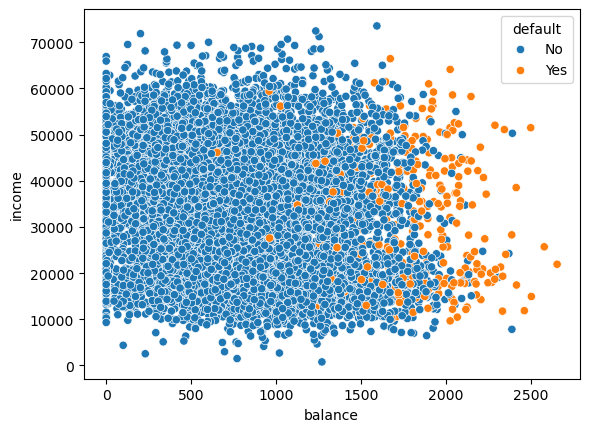

In [43]:
sns.scatterplot(data=df, x="balance", y = "income", hue="default")

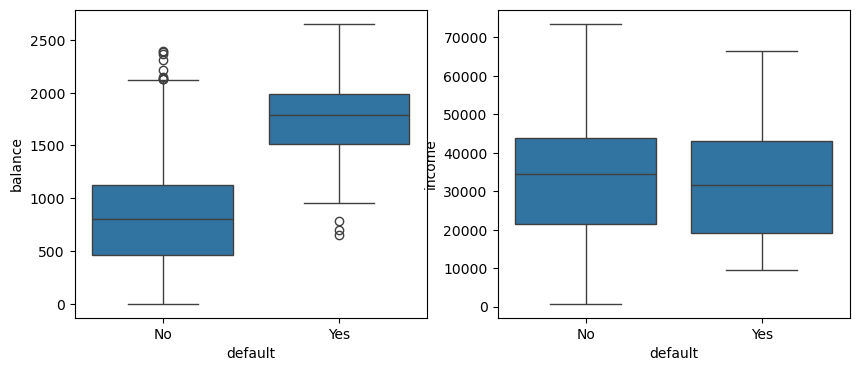

In [44]:
fig, ax = plt.subplots(1, 2, dpi=100, figsize=(10,4))

for axi, col in zip(ax, ["balance", "income"]):
    sns.boxplot(data=df, x="default", y=col, ax=axi)

## One-hot encoding

The features default and student are categorical. In order to make calculations on those variables, we need to represent them using dummy variables. There are two common types, dummy variables and one-hot encodings.

In [45]:
df_tmp = pd.get_dummies(df, columns=["default", "student"], drop_first=False) # one-hot encoding
df_tmp.head()

,balance,income,default_No,default_Yes,student_No,student_Yes
0,729.526495,44361.625074,True,False,True,False
1,817.180407,12106.134700,True,False,False,True
2,1073.549164,31767.138947,True,False,True,False
3,529.250605,35704.493935,True,False,True,False
4,785.655883,38463.495879,True,False,True,False


In [46]:
df = pd.get_dummies(df, columns=["default", "student"], drop_first=True) # dummy encoding
df.head()

,balance,income,default_Yes,student_Yes
0,729.526495,44361.625074,False,False
1,817.180407,12106.134700,False,True
2,1073.549164,31767.138947,False,False
3,529.250605,35704.493935,False,False
4,785.655883,38463.495879,False,False


---
## Logistic function 

The response variable that we want to predict is qualitative or categorical. We want to model the conditional probability of default given the balance

$p(X) = P(\textnormal{default = yes|balance}) = P(Y=1|X)$

For example p > 0.5, means we predict a certain person will default with higher than 0.5 probability. Must model $p(X)$ s.t. $p(X)\in[0,1]$. We begin with 

$p(X) = \frac{e^{\beta_0+\beta_1X}}{1+e^{\beta_0+\beta_1X}}$

Text(0.5, 1.0, 'Logistic function')

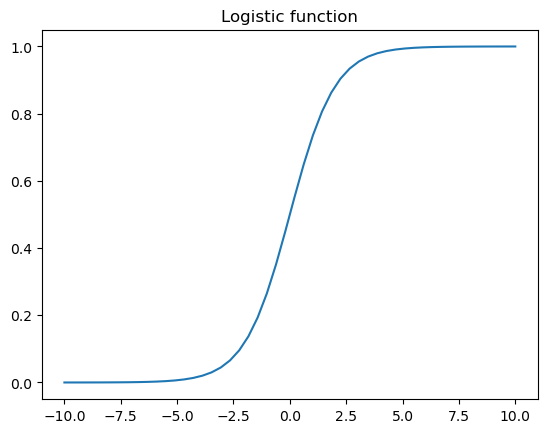

In [47]:
logistic_function = lambda x: np.exp(x)/(1+np.exp(x))

x = np.linspace(-10, 10)
plt.plot(x, logistic_function(x))
plt.title("Logistic function")

### Odds

A convenient way to talk about how a variable relates to another one is to use odds ratio, which is a statistics that can vary from 0 to $\infty$. The odds of a default vs not a default is given by this fraction of probability: 

$$\frac{p(X)}{1-p(X)} = e^{\beta_0+\beta_1X}$$

For example on average 3 of 10 gets a default is given by $0.3/0.7 = 3/7$.

We take logarithm of both sides and obtain the log odds or logit

$$\log{\left(\frac{p(X)}{1-p(X)} \right)} = \beta_0 + \beta_1X$$

This model is linear in $X$ and the parameters $\beta_0, \beta_1$ are chosen to maximize the likelihood function

$$l(\beta_0, \beta_1) = \prod_{y_i = 1}p(x_i)\prod_{y_j=0}(1-p(x_j))$$

In practice the log likelihood function is maximized using an optimization alogrithm such as batch gradient descent, mini-batch gradient descent or stochastic gradient descent.  

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X, y = df.drop("default_Yes", axis=1), df["default_Yes"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

model = LogisticRegression(penalty='l2')
model.fit(scaled_X_train, y_train)
model.coef_, model.intercept_

(array([[ 2.83066218,  0.0095274 , -0.27466992]]), array([-6.26854245]))

In [49]:
test_sample = pd.DataFrame({"balance": [1500, 1500], "income":[40000, 40000], "student_Yes": [0,1]})
scaled_test_sample = scaler.transform(test_sample)
print(test_sample)
model.predict_proba(scaled_test_sample)

   balance  income  student_Yes
0     1500   40000            0
1     1500   40000            1


array([[0.90028345, 0.09971655],
       [0.94279363, 0.05720637]])

In [50]:
y_pred = model.predict_proba(scaled_X_test)
y_pred[:5]

array([[9.29649665e-01, 7.03503348e-02],
       [9.98410011e-01, 1.58998929e-03],
       [9.99982519e-01, 1.74809051e-05],
       [9.99965852e-01, 3.41484328e-05],
       [9.53472728e-01, 4.65272724e-02]])

---

## Evaluation metrics for classification

Confusion matrix

||Pos prediction|Neg prediction|
|---|---|---|
|Pos class|TP|FN|
|Neg class|FP|TN|

- accuracy - ratio of correct predictions to all predictions
    - bad measure when, dataset class is imbalanced, e.g. a fraud model that always predicts non fraudulent could achieve accuracy of close to 1 without having any predictive power. 
- precision - number of positive class predictions that belong to positive class
    - good measure when FP is allowed to be higher e.g. email spam classification 
- recall - sensitivity - number of positive class predictions out of all positive examples 
    - good measure when there is high cost with FN e.g. sick patient of a contageous disease such as Covid-19 quick test
- $F_1$ score - harmonic mean between precision and recall 
    - seeks a balance between precision, recall and uneven class distributions

$ acc = \frac{TP+TN}{Total} $

$ prec = \frac{TP}{TP+FP}$

$ rec = \frac{TP}{TP+FN}$

$ F_1 = 2\frac{prec\cdot recall}{prec + rec}$

Accuracy: 0.973


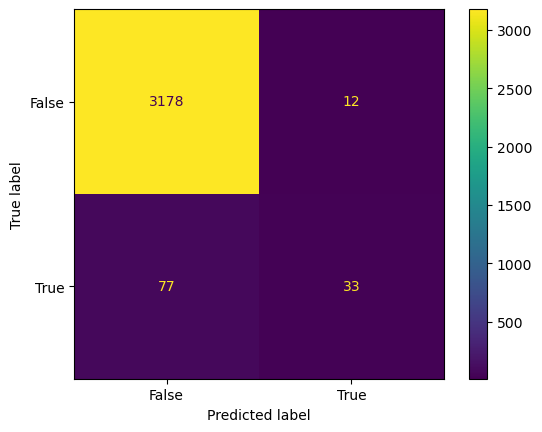

In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score

y_pred = model.predict(scaled_X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.3f}")
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
displ = ConfusionMatrixDisplay(cm, display_labels=model.classes_)
displ.plot()

In [52]:
accuracy = (3178+33)/(3178+12+77+33)
recall = 33/(33+77)
precision = 33/(33+12)
f1 = 2*recall*precision/(recall+precision)
accuracy, recall, precision, f1

(0.973030303030303, 0.3, 0.7333333333333333, 0.4258064516129032)

In [53]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.98      1.00      0.99      3190
        True       0.73      0.30      0.43       110

    accuracy                           0.97      3300
   macro avg       0.85      0.65      0.71      3300
weighted avg       0.97      0.97      0.97      3300

